In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv("/kaggle/input/datasets/akram24/social-network-ads/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [25]:
df2=df.iloc[:,2:]
df2.sample(4)

,Age,EstimatedSalary,Purchased
393,60,42000,1
178,24,23000,0
4,19,76000,0
252,48,134000,1


## Train Test Split

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df2.drop("Purchased",axis=1),
                                               df2["Purchased"],
                                               test_size=0.3,
                                               random_state=0)

X_train.shape,X_test.shape

((280, 2), (120, 2))

## Standard Scaler

In [37]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

#fit the scaler to the train set, it'll learn the parameters
scaler.fit(X_train) # we only learn from training data

#transform train and test sets and we transform both the datasets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [29]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

### the problem wit scaling data is that it gives us numpy array ,so we'll convert it into pandas dataframe

In [39]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_Scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [36]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [40]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## Effect of scaling

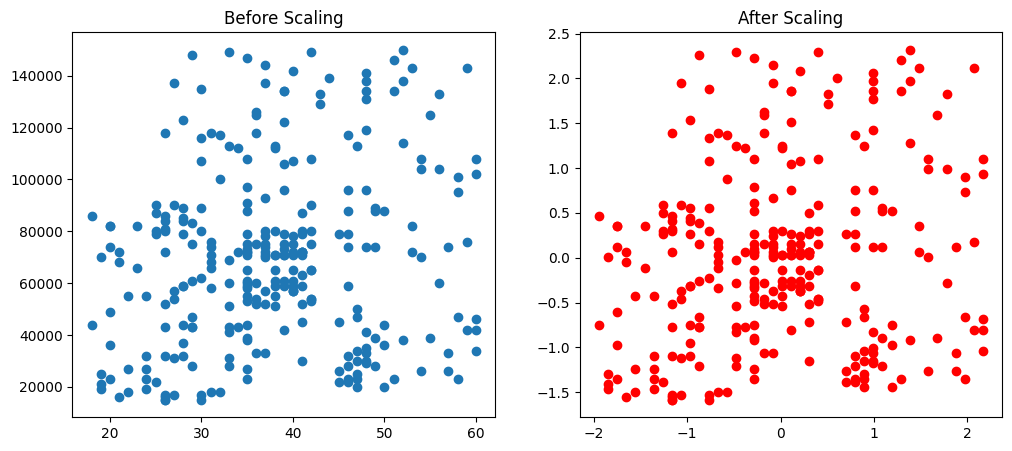

In [41]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

### PDF (Probability Density Function) of Age and EstimatedSalary

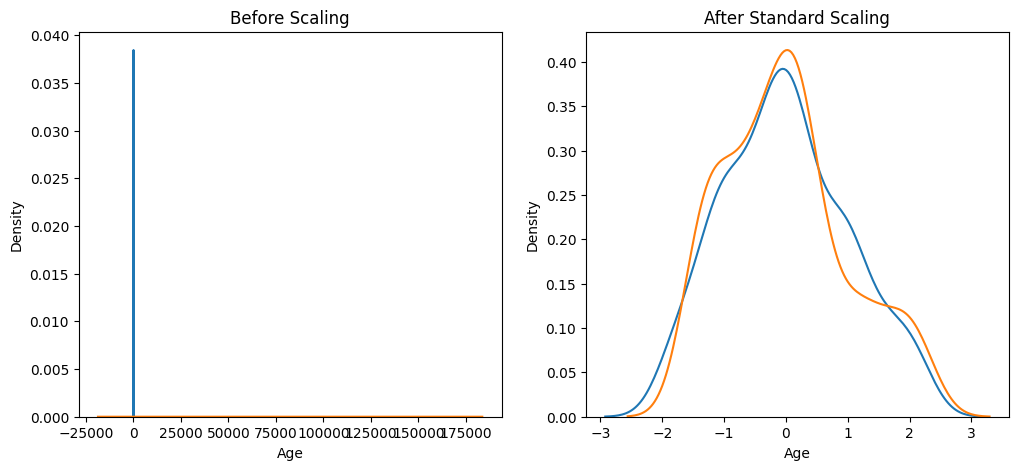

In [43]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

### Comparison of Distributions

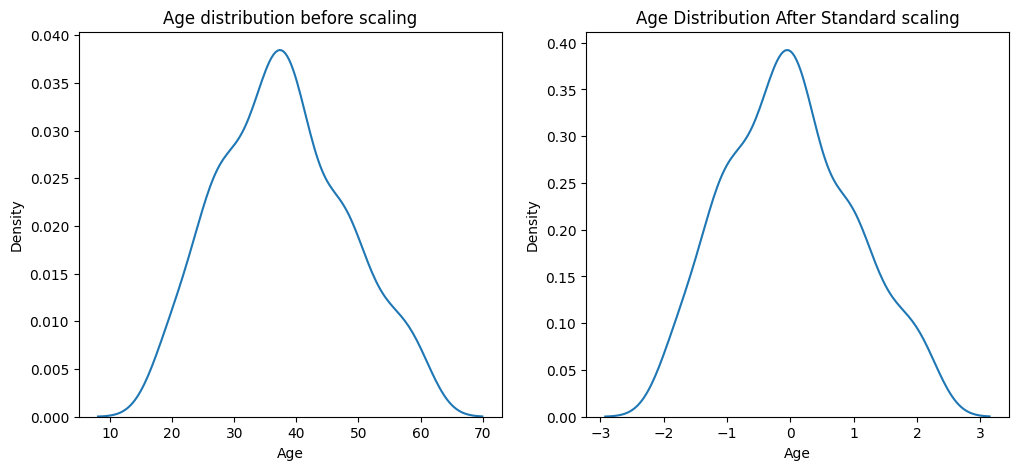

In [44]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title('Age distribution before scaling')
sns.kdeplot(X_train['Age'],ax=ax1)

# After scaling
ax2.set_title('Age Distribution After Standard scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
plt.show()

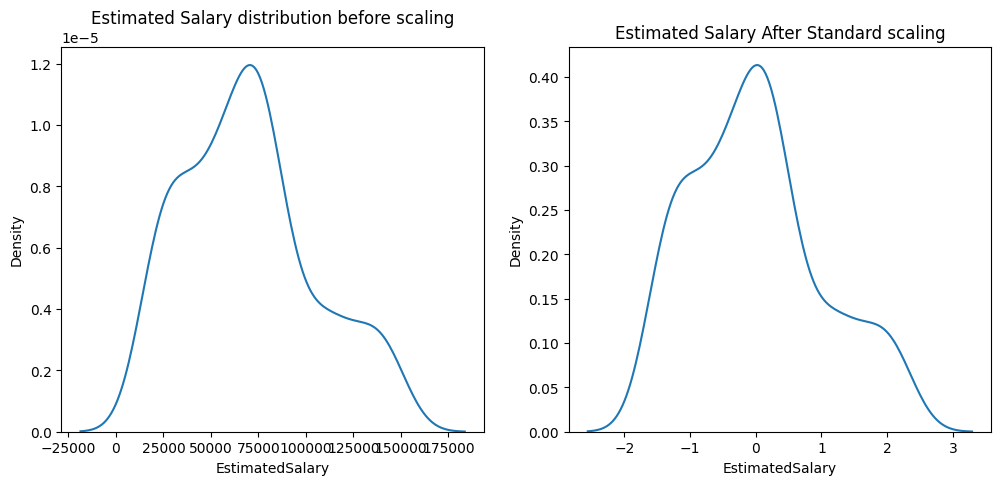

In [45]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title('Estimated Salary distribution before scaling')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# After scaling
ax2.set_title('Estimated Salary After Standard scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

### Why scaling is important?

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [49]:
lr.fit(X_train,y_train)

LogisticRegression()

In [50]:
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [52]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [54]:
from sklearn.metrics import accuracy_score

In [55]:
print(f"Actual: {accuracy_score(y_test,y_pred)}")
print(f"Scaled:{accuracy_score(y_test,y_pred_scaled)}")

Actual: 0.875
Scaled:0.8666666666666667


### Lets try decision tree algorithm

In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

In [58]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [59]:
y_pred=dt.predict(X_test)
y_pred_scaled=dt_scaled.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [60]:
print(f"Actual: {accuracy_score(y_test,y_pred)}")
print(f"Scaled:{accuracy_score(y_test,y_pred_scaled)}")

Actual: 0.8666666666666667
Scaled:0.8666666666666667


In [61]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000
